# Design & Build a Neo4j Knowledge Graph

## 1a. Introduction

The assignment requires importing Chinook database content (Artist, Album, Track, Genre, and MediaType tables) from five CSV files into a Neo4j graph database, then constructing Cypher queries to retrieve specific data. Graph databases perform better for this domain because the artist–album–track relationships form a natural interconnected structure rather than joining multiple tables, we can traverse relationships directly between nodes, which simplifies queries and can improve performance for path-based lookups. This document describes how I will tackle the problem and what challenges to expect.

The approach will proceed in the following order: 
- designing an appropriate graph schema, 
- establishing the correct load order for dependencies, 
- implementing the import and relationships using Cypher, 
- validating the graph and executing the required queries.

---

## 1b. Planned Approach

### Schema Design

I will map the relational Chinook entities to the following graph model:

**Nodes**
- Artist
    - artistId
    - name
- Album
  - albumId
  - title

- Track
  - trackId
  - name
  - milliseconds
  - bytes
  - unitPrice 
- Genre
  - genreId
  - name
- MediaType
  - mediaTypeId
  - name
- Composer
  - name

**Relationships**:
  - `(Artist)-[:RELEASED]->(Album)` ,each album is released by one artist
  - `(Album)-[:CONTAINS]->(Track)` , each album contains one or more tracks
  - `(Track)-[:IN_GENRE]->(Genre)` , each track belongs to one genre
  - `(Track)-[:OF_MEDIA_TYPE]->(MediaType)` , each track has one media type
  - `(Track)-[:COMPOSED_BY]->(Composer)` , each track is composed by a composer

**Constraints**
These enforce uniqueness and prevent duplicate nodes during imports:
- artistId (Artist)
- albumId (Album)
- trackId (Track)
- genreId (Genre)
- mediaTypeId (MediaType)
- name (Composer)

**Indexes**
Help speed up lookups by name/title for the required queries:
- name (Artist) 
- title (Album)
- name (Genre)
- name (MediaType)
- name (Composer)

### Data Loading Strategy

Data must be imported in dependency order to support relationship creation:

1. Genre and MediaType first because they have no dependencies, lookup/reference tables
2. Artist has no dependencies on other Chinook tables
3. Album references Artist 
4. Track references Album, Genre, and MediaType 
5. Composer because its derived from Track

###  Execution

Using Neo4j Browser, I will first create constraints then run `LOAD CSV` commands for each CSV file using `MERGE` rather than `CREATE` to avoid duplicate nodes when re-running imports. The csv file contain headers so I will use `WITH HEADERS`. I will convert each column to the appropraite data types eg converting to integers or floats. After that I will run Cypher queries to create the relationships by matching nodes on their identifier properties. I will also the run the additional  indexes for query optimization

### Validation and Querying

I will confirm success by:
 - visualizing the graph in Neo4j Browser, 
 - run sample traversals to verify the structure, 
 - implement the six required Cypher queries. 

---

## 1c. Anticipated Data Challenges
- query (f) indicates that the data contains null or missing values, so there is a need for a way to handle null values
- handling duplicate data found in changing composer from property to a node 
- some queries are case-sensitive eg 'Bongo Fury' can not be 'Bongo fury'
- some relationships and nodes can not be created until the referenced nodes are inplace
- data containing commas should not be mistaken as seperate columns eg "Love, Hate, Love"
- data duplication during imports


## 2 Implementation of Plan

This section documents the step-by-step implementation of importing Chinook data into Neo4j, following the planned approach outlined in Section 1. The implementation proceeds in the correct dependency order: first establishing constraints and indexes, then loading nodes, and finally creating relationships.

### 2.1 Constraints and Indexes

Constraints and indexes are created **before** loading data to ensure data integrity and optimize query performance. Constraints enforce uniqueness on identifier properties, preventing duplicate nodes during imports, while indexes speed up lookups by name and title properties used in the required queries.

- I ran the following commands in the Neo4j-browser to create constraints
```
CREATE CONSTRAINT artist_id IF NOT EXISTS FOR (a:Artist) REQUIRE a.artistId IS UNIQUE;
CREATE CONSTRAINT album_id IF NOT EXISTS FOR (a:Album) REQUIRE a.albumId IS UNIQUE;
CREATE CONSTRAINT track_id IF NOT EXISTS FOR (t:Track) REQUIRE t.trackId IS UNIQUE;
CREATE CONSTRAINT genre_id IF NOT EXISTS FOR (g:Genre) REQUIRE g.genreId IS UNIQUE;
CREATE CONSTRAINT mediatype_id IF NOT EXISTS FOR (m:MediaType) REQUIRE m.mediaTypeId IS UNIQUE;
CREATE CONSTRAINT composer_name IF NOT EXISTS FOR (c:Composer) REQUIRE c.name IS UNIQUE;
```
- These commands create primary keys and indexes for the following nodes respectively
    - Artist node, for each artist_id, enforce uniqueness constraint on artistId for each entry and create index on artistId
    - Album node, for each album_id, enforce uniqueness constraint on albumId for each entry and create index on albumId
    - Track node, for each track_id, enforce uniqueness constraint on trackId for each entry and create index on trackId
    - Genre node, for each genre_id, enforce uniqueness constraint on genreId for each entry and create index on genreId
    - MediaType node, for each mediatype_id, enforce uniqueness constraint on mediaTypeId for each entry and create index on mediatypeId

I also created additional indexes to help query the graph for faster results:
```
CREATE INDEX artist_name IF NOT EXISTS FOR (a:Artist) ON (a.name);
CREATE INDEX album_title IF NOT EXISTS FOR (a:Album) ON (a.title);
CREATE INDEX genre_name IF NOT EXISTS FOR (g:Genre) ON (g.name);
CREATE INDEX mediatype_name IF NOT EXISTS FOR (m:MediaType) ON (m.name);
```
- These create additional indexes (beyond those created by constraints) for query optimization:
    - **Artist node**: Index on the `name` property (called `artist_name`) - speeds up queries filtering by artist name
    - **Album node**: Index on the `title` property (called `album_title`) - speeds up queries filtering by album title
    - **Genre node**: Index on the `name` property (called `genre_name`) - speeds up queries filtering by genre name
    - **MediaType node**: Index on the `name` property (called `mediatype_name`) - speeds up queries filtering by media type name

- The `IF NOT EXISTS` clause checks if an index or constraint with the same name already exists before creating it, preventing errors when re-running the import script
- I then ran `SHOW INDEXES` to confirm all indexes and constraints were created successfully

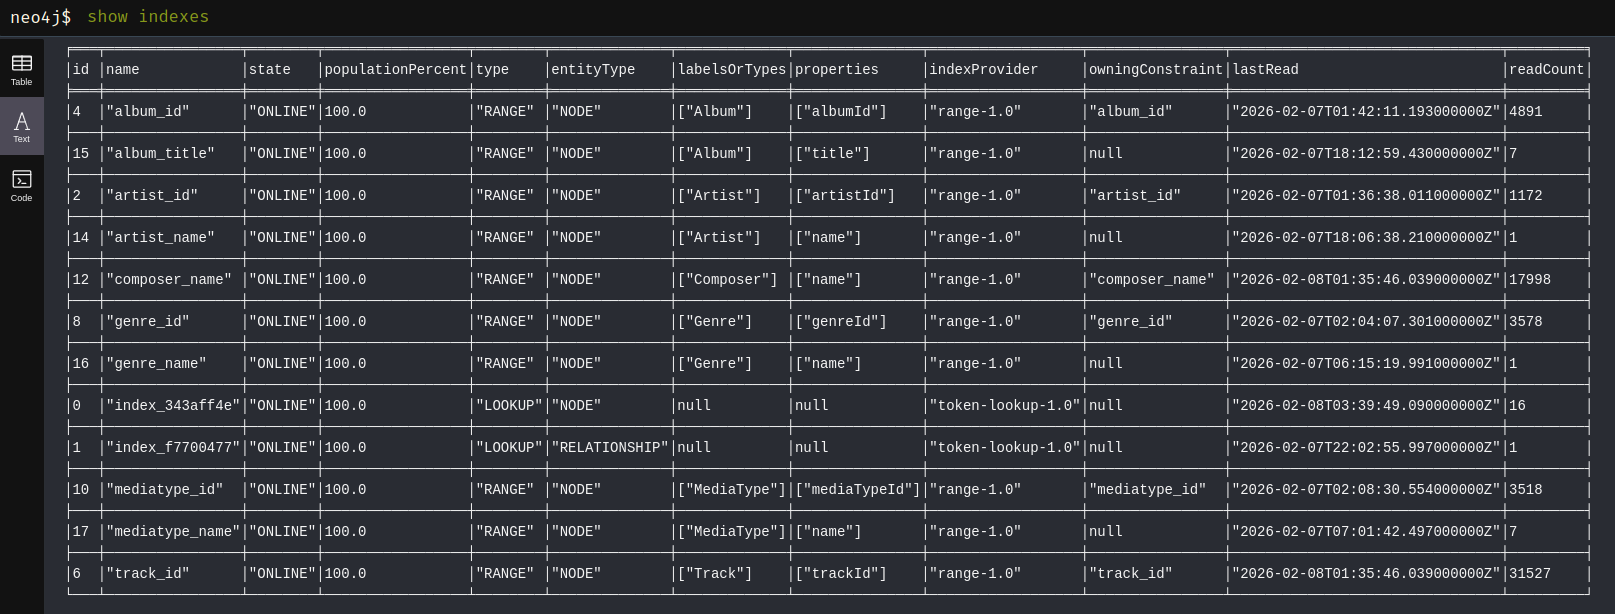
    

### 2.2 Loading Nodes

Nodes are loaded in dependency order to ensure that referenced nodes exist before creating relationships. We start with Genre and MediaType since they have no dependencies and serve as lookup/reference tables.

#### Preparing CSV Files

- To upload CSV files, first add them to the import folder of the database
- In Neo4j Desktop, hover on the database and click the 3 dots at the far right to reveal the dropdown options, then click the 'Open Folder' option, which will take you to the import folder, as shown in the image below:

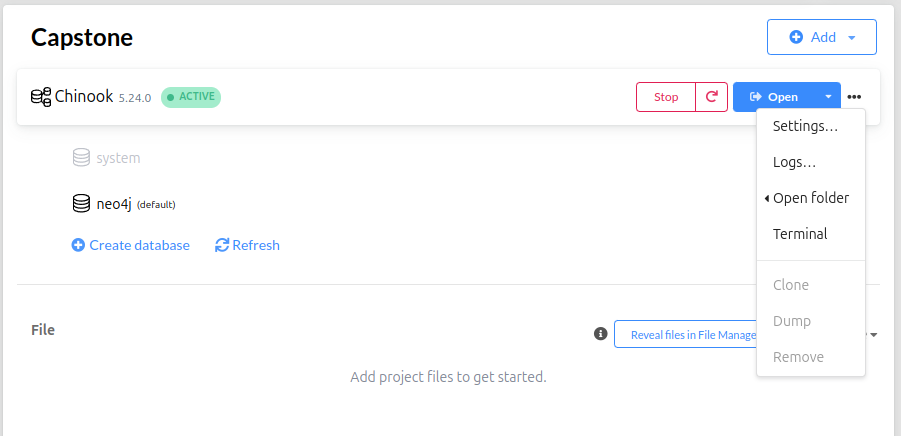

- Copy the CSV files into that folder
- Now loading can begin as per the data loading strategy outlined in the planned approach

#### 2.2.1 Loading Genre Nodes
``` 
LOAD CSV WITH HEADERS FROM 'file:///Genre.csv' AS row
MERGE (g:Genre {genreId: toInteger(row.GenreId)})
SET g.name = row.Name; 

```

**Explanation:**
- For the Genre Node, we use the `Genre.csv` file to extract the nodes
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. It checks if a node with the same `genreId` already exists (using the uniqueness constraint we created earlier). If it exists, it updates it; if not, it creates a new node
- For each node, we add the label `Genre` and set the `name` property using the `SET` command
- The `toInteger()` function converts the CSV string value to an integer for the `genreId` property, ensuring proper data type
- Since the CSV contains 25 rows of data (excluding the header), we expect 25 nodes and 50 properties (each node has `genreId` and `name` properties)

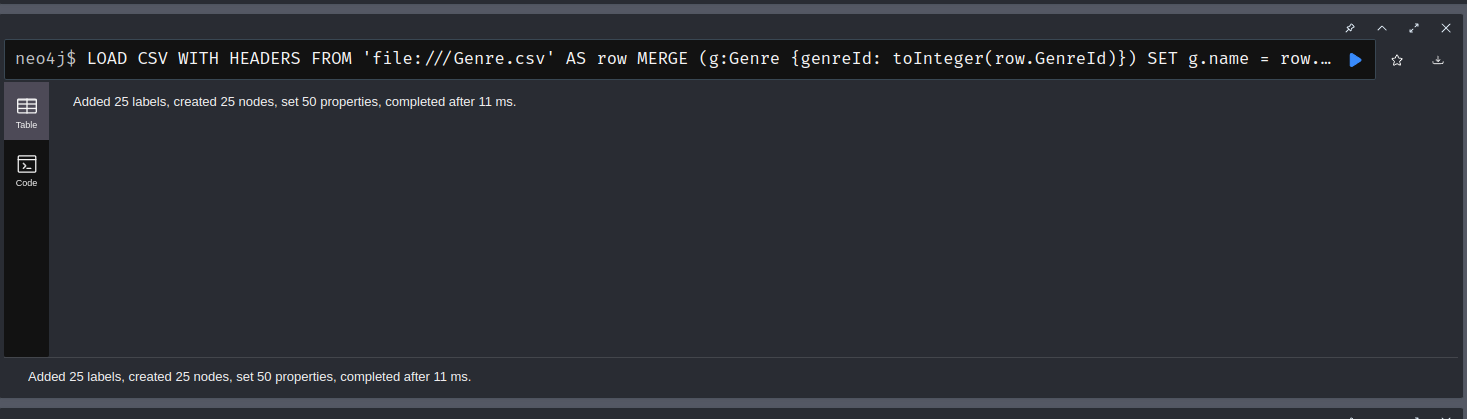

**Result:** Query executed successfully, producing 25 nodes, 25 labels, and 50 properties.

**Verification:**
We can verify the Genre nodes were loaded correctly by running:
```cypher
MATCH (g:Genre) RETURN count(g) AS genre_count;
```
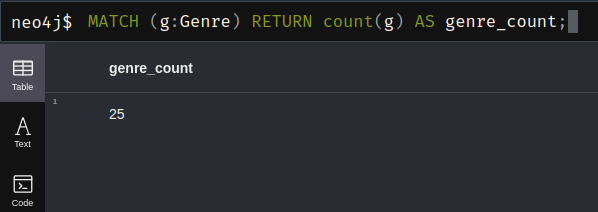

This confirms we have 25 Genre nodes in the database.

#### 2.2.2 Loading MediaType Nodes

```
LOAD CSV WITH HEADERS FROM 'file:///MediaType.csv' AS row
MERGE (m:MediaType {mediaTypeId: toInteger(row.MediaTypeId)})
SET m.name = row.Name;
```

**Explanation:**
- For the MediaType Node, we use the `MediaType.csv` file to extract the nodes
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. It checks if a node with the same `mediaTypeId` already exists (using the uniqueness constraint we created earlier). If it exists, it updates it; if not, it creates a new node
- For each node, we add the label `MediaType` and set the `name` property using the `SET` command
- The `toInteger()` function converts the CSV string value to an integer for the `mediaTypeId` property, ensuring proper data type
- Since the CSV contains 5 rows of data (excluding the header), we expect 5 nodes and 10 properties (each node has `mediaTypeId` and `name` properties)

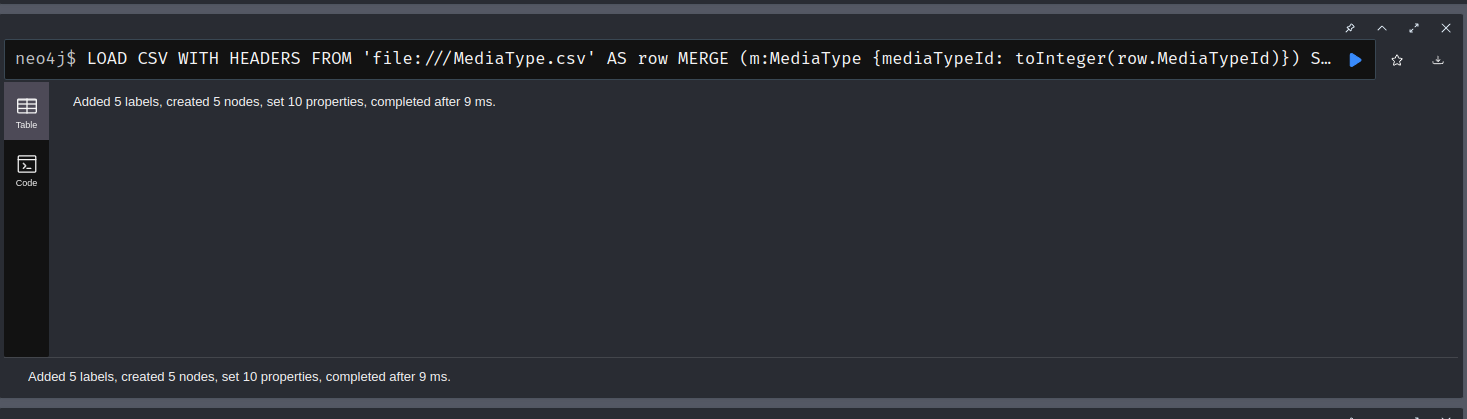

**Result:** Query executed successfully, producing 5 nodes, 5 labels, and 10 properties.

**Verification:**
We can verify the MediaType nodes were loaded correctly by running:
```cypher
MATCH (m:MediaType) RETURN count(m) AS mediatype_count;
```
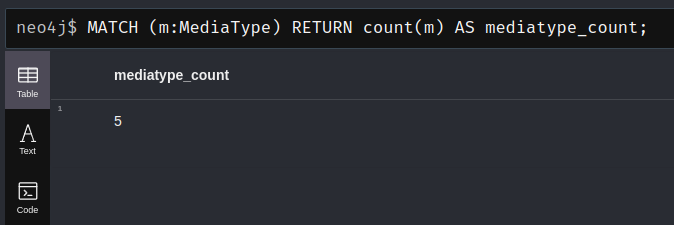

This confirms we have 5 MediaType nodes in the database.

#### 2.2.3 Loading Artist Nodes


```cypher
LOAD CSV WITH HEADERS FROM 'file:///Artist.csv' AS row
MERGE (a:Artist {artistId: toInteger(row.ArtistId)})
SET a.name = row.Name;
```
**Explanation:**
- For the Artist Node, we use the `Artist.csv` file to extract the nodes
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. It checks if a node with the same `artistId` already exists (using the uniqueness constraint we created earlier). If it exists, it updates it; if not, it creates a new node
- For each node, we add the label `Artist` and set the `name` property using the `SET` command
- The `toInteger()` function converts the CSV string value to an integer for the `artistId` property, ensuring proper data type
- Artist nodes are loaded third in our dependency order because they have no dependencies on other Chinook tables
- Since the CSV contains 275 rows of data (excluding the header), we expect 275 nodes and 550 properties (each node has `artistId` and `name` properties)

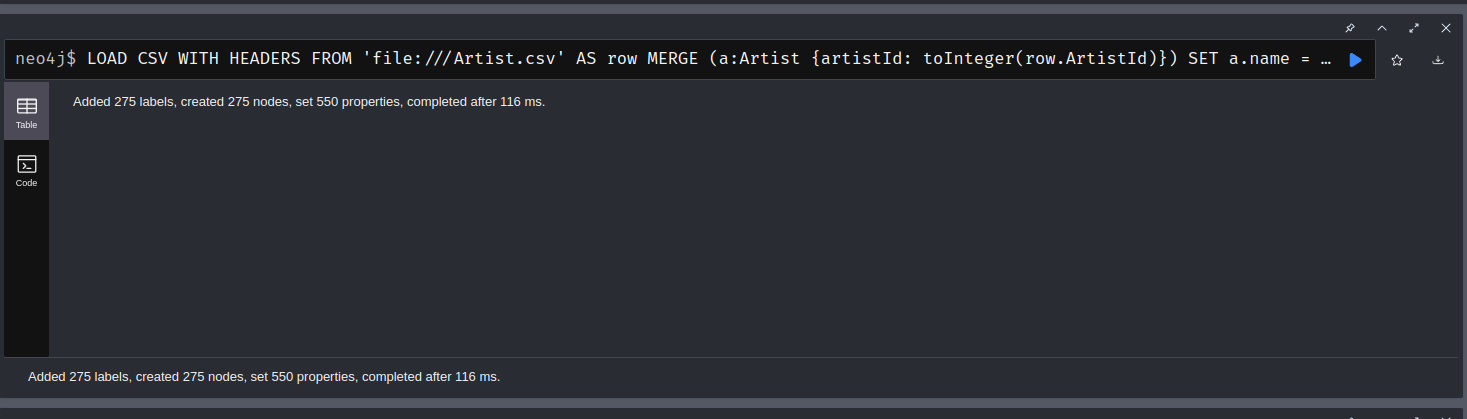

**Result:** Query executed successfully, producing 275 nodes, 275 labels, and 550 properties.

**Verification:**
We can verify the Artist nodes were loaded correctly by running:
```cypher
MATCH (a:Artist) RETURN count(a) AS artist_count;
```
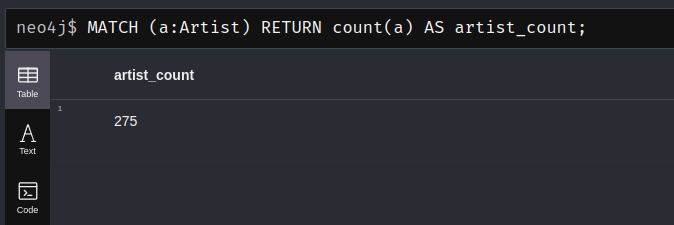

This confirms we have 275 Artist nodes in the database.

#### 2.2.4 Loading Album Nodes


```
LOAD CSV WITH HEADERS FROM 'file:///Album.csv' AS row
MERGE (a:Album {albumId: toInteger(row.AlbumId)})
SET a.title = row.Title;
```

**Explanation:**
- For the Album Node, we use the `Album.csv` file to extract the nodes
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. It checks if a node with the same `albumId` already exists (using the uniqueness constraint we created earlier). If it exists, it updates it; if not, it creates a new node
- For each node, we add the label `Album` and set the `title` property using the `SET` command
- The `toInteger()` function converts the CSV string value to an integer for the `albumId` property, ensuring proper data type
- Album nodes are loaded fourth in our dependency order because they reference Artist via `ArtistId`. Note that we load only the Album nodes here; the relationships to Artist will be created separately in the next section
- Since the CSV contains 374 rows of data (excluding the header), we expect 374 nodes and 748 properties (each node has `albumId` and `title` properties)

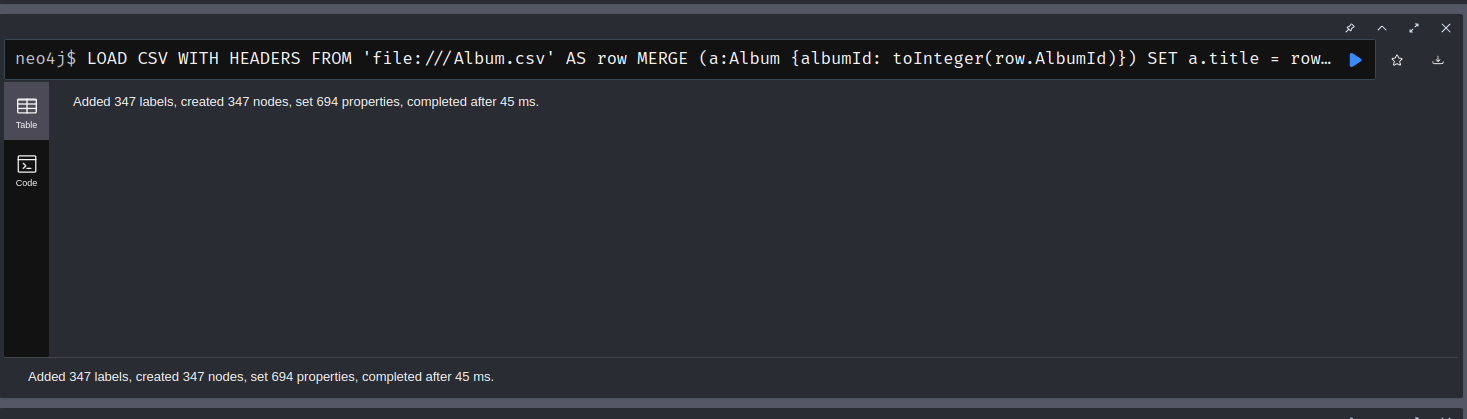

**Result:** Query executed successfully, producing 374 nodes, 374 labels, and 748 properties.

**Verification:**
We can verify the Album nodes were loaded correctly by running:
```cypher
MATCH (a:Album) RETURN count(a) AS album_count;
```
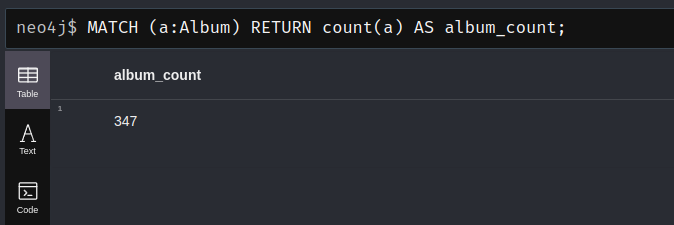

This confirms we have 374 Album nodes in the database.

#### 2.2.5 Loading Track Nodes


```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
MERGE (t:Track {trackId: toInteger(row.TrackId)})
SET t.name = row.Name,
    t.milliseconds = toInteger(row.Milliseconds),
    t.bytes = toInteger(row.Bytes),
    t.unitPrice = toFloat(row.UnitPrice);
```
**Explanation:**
- For the Track Node, we use the `Track.csv` file to extract the nodes
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. It checks if a node with the same `trackId` already exists (using the uniqueness constraint we created earlier). If it exists, it updates it; if not, it creates a new node
- For each node, we add the label `Track` and set multiple properties: `name`, `milliseconds`, `bytes`, and `unitPrice`
- Data type conversions are critical here:
  - `toInteger(row.Milliseconds)` converts the milliseconds value to an integer
  - `toInteger(row.Bytes)` converts the bytes value to an integer
  - `toFloat(row.UnitPrice)` converts the unit price to a floating-point number
- Track nodes are loaded fifth in our dependency order because they reference Album, Genre, and MediaType via foreign keys. Note that we load only the Track nodes here; the relationships will be created separately in the next section
- Since the CSV contains 3,503 rows of data (excluding the header), we expect 3,503 nodes and 17,515 properties (each node has 5 properties: `trackId`, `name`, `milliseconds`, `bytes`, and `unitPrice`)

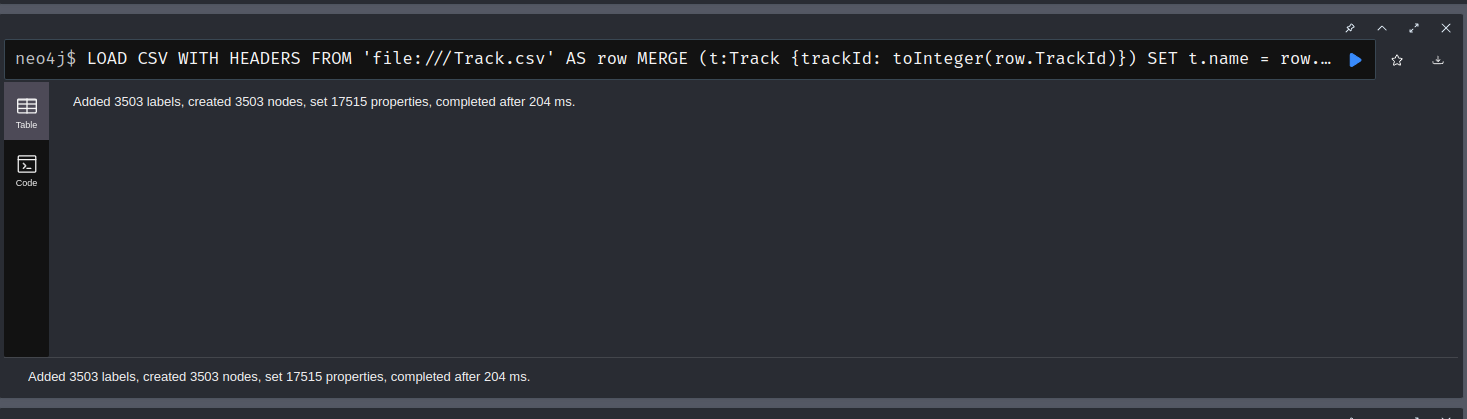

**Result:** Query executed successfully, producing 3,503 nodes, 3,503 labels, and 17,515 properties.

**Verification:**
We can verify the Track nodes were loaded correctly by running:
```cypher
MATCH (t:Track) RETURN count(t) AS track_count;
```
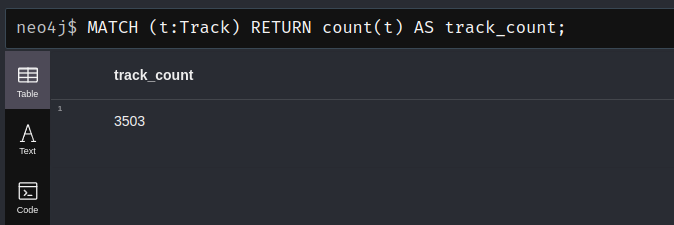

This confirms we have 3,503 Track nodes in the database.

#### 2.2.6 Loading Composer Nodes


```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
WITH row
WHERE row.Composer IS NOT NULL 
  AND row.Composer <> '' 
  AND row.Composer <> 'NULL'
  AND trim(row.Composer) <> ''
MERGE (c:Composer {name: row.Composer});
```

**Explanation:**
- For the Composer Node, we derive the nodes from the `Track.csv` file (there is no separate Composer CSV file)
- The CSV file contains headers, so we use `WITH HEADERS` to tell Neo4j that the first row contains column names
- **NULL handling is critical here**: We filter out rows where the Composer field is NULL, empty, or contains the string 'NULL' using the WHERE clause:
  - `row.Composer IS NOT NULL` - ensures the field exists
  - `row.Composer <> ''` - filters out empty strings, ```trim``` removes whitespaces
  - `row.Composer <> 'NULL'` - filters out the literal string "NULL" (CSV NULL values are often read as strings)
- `MERGE` is used instead of `CREATE` to avoid creating duplicates. Since there is no `ComposerId` in the source data, we use the `name` property as the unique identifier (enforced by our uniqueness constraint)
- For each unique composer string, we create a Composer node with only the `name` property
- Composer nodes are loaded last (sixth) in our dependency order because they are derived from Track data. Note that we load only the Composer nodes here; the relationships to Track will be created separately in the next section
- Since there are 852 unique composer strings in the Track data (excluding NULL values), we expect 852 nodes and 852 properties (each node has only the `name` property)

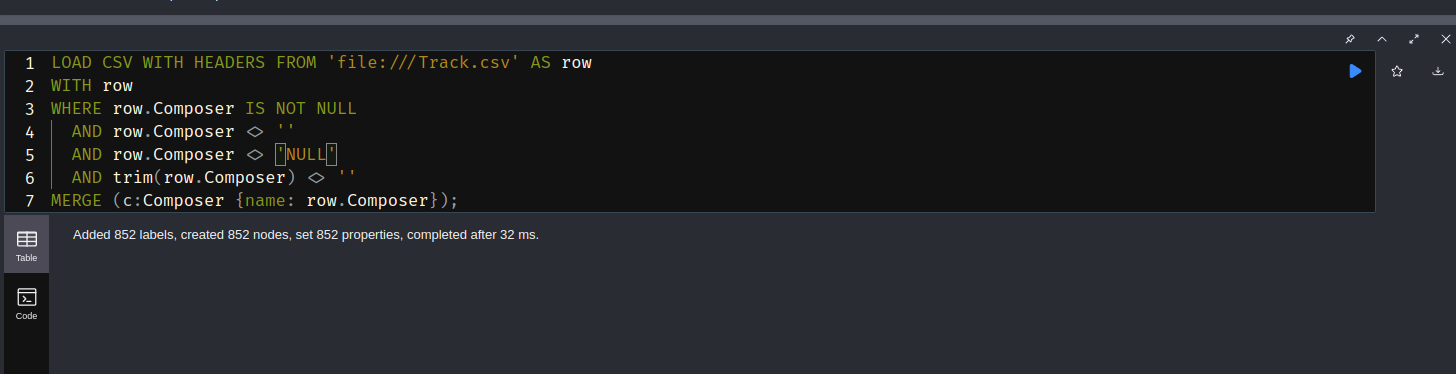

**Result:** Query executed successfully, producing 852 nodes, 852 labels, and 852 properties.

**Verification:**
We can verify the Composer nodes were loaded correctly by running:
```cypher
MATCH (c:Composer) RETURN count(c) AS composer_count;
```
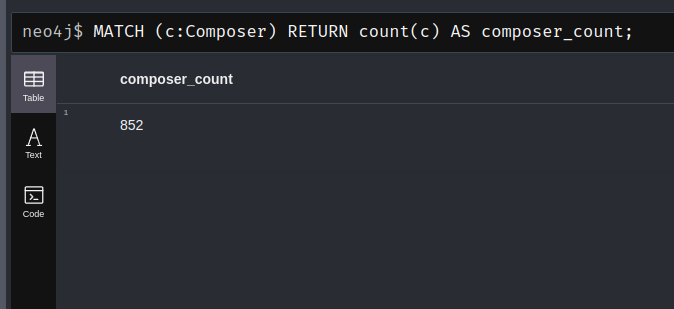

This confirms we have 852 Composer nodes in the database.

## 2.3 Loading Relationships
I created relationships which respected the Chinook original relational database relationships, with an additional ```COMPOSED_BY``` relationship that comes with the ```Composer``` node.
The implemented relationships were as follows:
  - `(Artist)-[:RELEASED]->(Album)`, each album is released by one artist
  - `(Album)-[:CONTAINS]->(Track)`, each album contains one or more tracks
  - `(Track)-[:IN_GENRE]->(Genre)`, each track belongs to one genre
  - `(Track)-[:OF_MEDIA_TYPE]->(MediaType)`, each track has one media type
  - `(Track)-[:COMPOSED_BY]->(Composer)`, each track is composed by a composer


### 2.3.1 RELEASED Relationship

**Relationship Details:**
- **Directionality**: Directed from Artist to Album (Artist *RELEASED* Album)
- **Cardinality**: One-to-many (each Artist can release one or more Albums, each Album is released by exactly one Artist)
- **Properties**: None

**Implementation:**
The relationship is derived by loading the ```Album.csv``` file and matching the corresponding ArtistId to the artistId on the Artist node and AlbumId to the albumId on the Album node. Since the ```Album.csv``` contains 374 rows of data (excluding the header), we expect 374 ```RELEASED``` relationships (one per album). The relationship is created with the following query:

```
LOAD CSV WITH HEADERS FROM 'file:///Album.csv' AS row
MATCH (artist:Artist {artistId: toInteger(row.ArtistId)})
MATCH (album:Album {albumId: toInteger(row.AlbumId)})
MERGE (artist)-[:RELEASED]->(album);
```

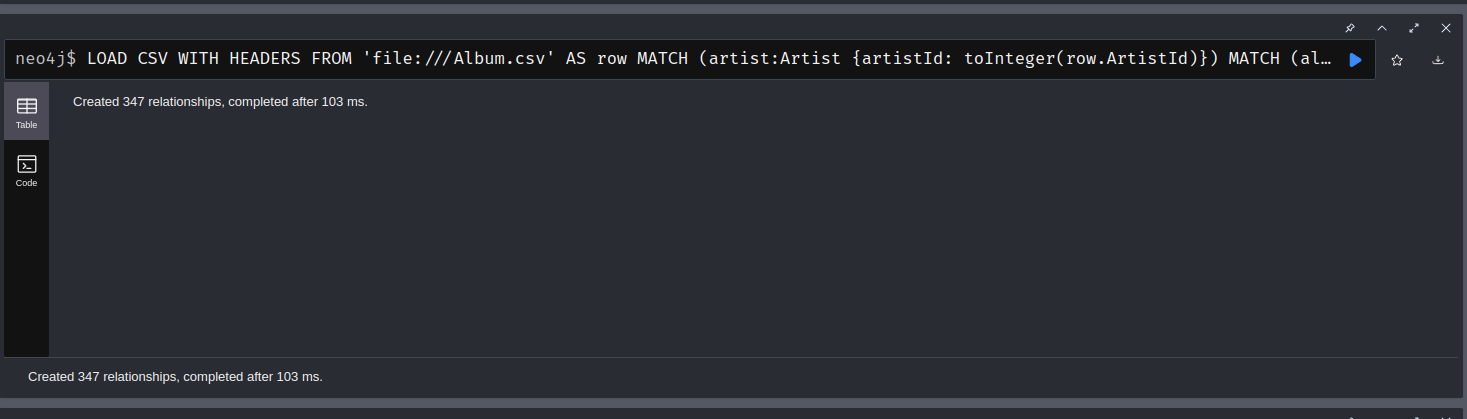

**Result:** This shows that the query ran successfully and produced 347 relationships.

### 2.3.2 CONTAINS Relationship

**Relationship Details:**
- **Directionality**: Directed from Album to Track (Album *CONTAINS* Track)
- **Cardinality**: One-to-many (each Album contains one or more Tracks, each Track belongs to exactly one Album)
- **Properties**: None

**Implementation:**
The relationship is derived by loading the ```Track.csv``` file and matching the corresponding AlbumId to the albumId on the Album node and TrackId to the trackId on the Track node. Since the ```Track.csv``` contains 3,503 rows of data (excluding the header), we expect 3,503 ```CONTAINS``` relationships (one per track). The relationship is created with the following query:



```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
MATCH (album:Album {albumId: toInteger(row.AlbumId)})
MATCH (track:Track {trackId: toInteger(row.TrackId)})
MERGE (album)-[:CONTAINS]->(track);
```

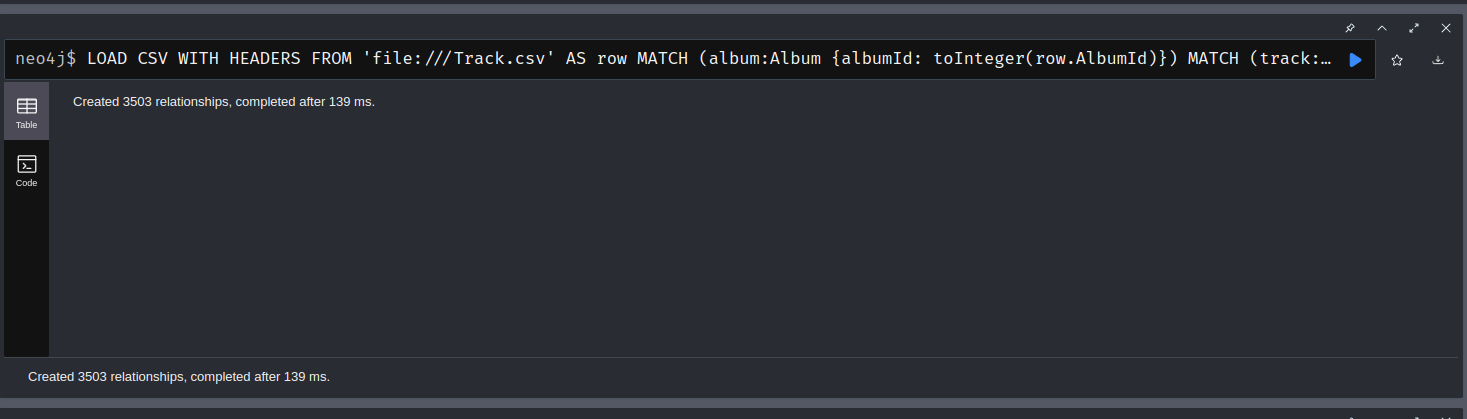

**Result:** This shows that the query ran successfully and produced 3,503 relationships.


### 2.3.3 IN_GENRE Relationship

**Relationship Details:**
- **Directionality**: Directed from Track to Genre (Track *IN_GENRE* Genre)
- **Cardinality**: Many-to-one (each Track belongs to exactly one Genre, each Genre can have one or more Tracks)
- **Properties**: None

**Implementation:**
The relationship is derived by loading the ```Track.csv``` file and matching the corresponding TrackId to the trackId on the Track node and GenreId to the genreId on the Genre node. Since the ```Track.csv``` contains 3,503 rows of data (excluding the header), we expect 3,503 ```IN_GENRE``` relationships (one per track). The relationship is created with the following query:



```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
MATCH (track:Track {trackId: toInteger(row.TrackId)})
MATCH (genre:Genre {genreId: toInteger(row.GenreId)})
MERGE (track)-[:IN_GENRE]->(genre);
```

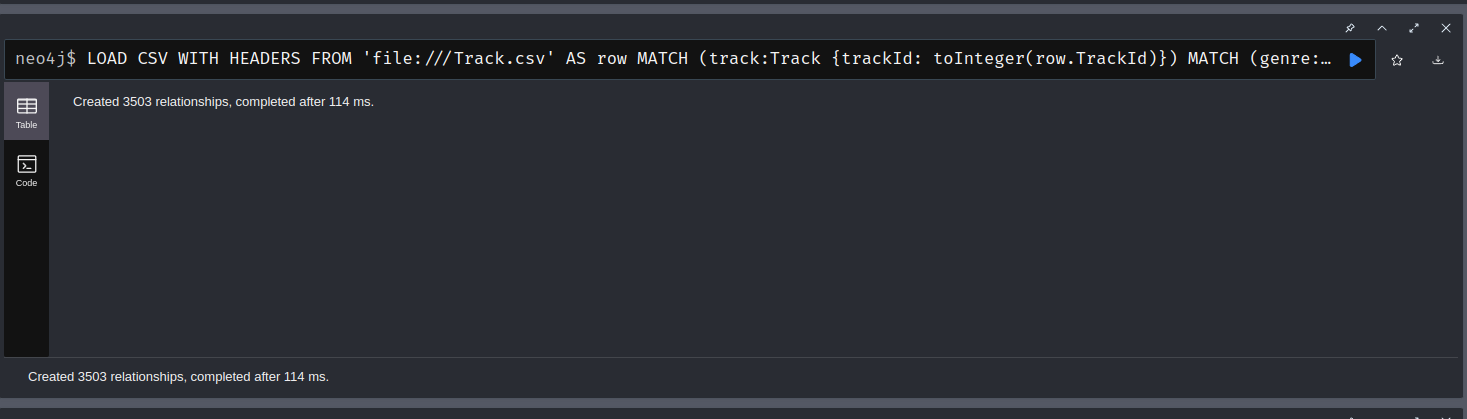

**Result:** This shows that the query ran successfully and produced 3,503 relationships.


### 2.3.4 OF_MEDIA_TYPE Relationship

**Relationship Details:**
- **Directionality**: Directed from Track to MediaType (Track *OF_MEDIA_TYPE* MediaType)
- **Cardinality**: Many-to-one (each Track has exactly one MediaType, each MediaType can be associated with one or more Tracks)
- **Properties**: None

**Implementation:**
The relationship is derived by loading the ```Track.csv``` file and matching the corresponding TrackId to the trackId on the Track node and MediaTypeId to the mediaTypeId on the MediaType node. Since the ```Track.csv``` contains 3,503 rows of data (excluding the header), we expect 3,503 ```OF_MEDIA_TYPE``` relationships (one per track). The relationship is created with the following query:



```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
MATCH (track:Track {trackId: toInteger(row.TrackId)})
MATCH (mediaType:MediaType {mediaTypeId: toInteger(row.MediaTypeId)})
MERGE (track)-[:OF_MEDIA_TYPE]->(mediaType);
```

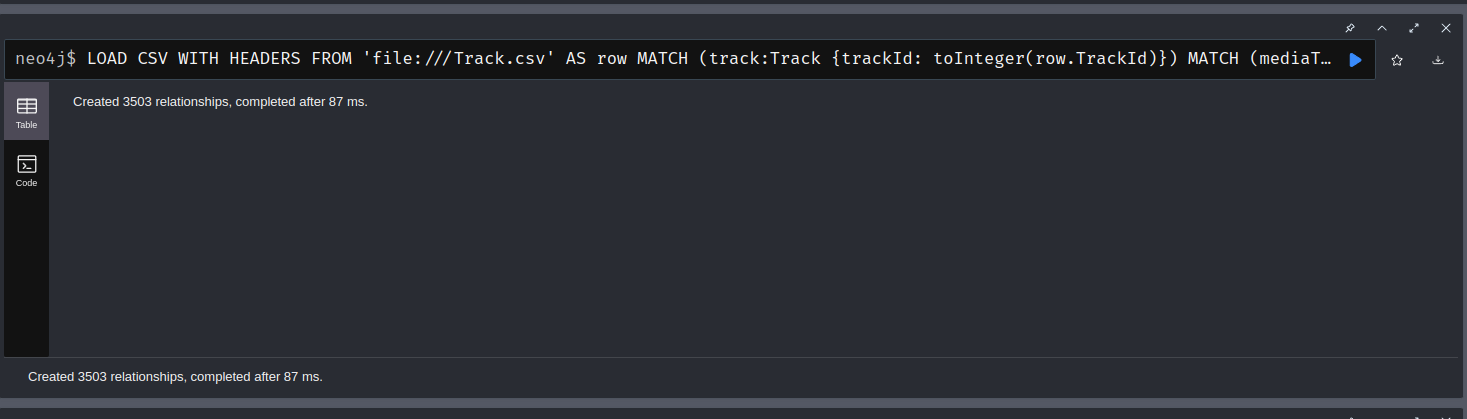

**Result:** This shows that the query ran successfully and produced 3,503 relationships.


### 2.3.5 COMPOSED_BY Relationship

**Relationship Details:**
- **Directionality**: Directed from Track to Composer (Track *COMPOSED_BY* Composer)
- **Cardinality**: Many-to-one (each Track can be composed by one Composer, each Composer can compose one or more Tracks)
- **Properties**: None

**Implementation:**
The relationship is derived by loading the ```Track.csv``` file and filtering out rows where the Composer field is ```NULL```, ```empty```, or ```contains the string 'NULL'```. Then matching the corresponding TrackId to the trackId on the Track node and Composer name to the name property on the Composer node. Since ```Track.csv``` contains 3,503 rows we expect less than 3,503 ```COMPOSED_BY``` relationships. The relationship is created with the following query:



```
LOAD CSV WITH HEADERS FROM 'file:///Track.csv' AS row
WITH row
WHERE row.Composer IS NOT NULL 
  AND row.Composer <> '' 
  AND row.Composer <> 'NULL'
  AND trim(row.Composer) <> ''
MATCH (track:Track {trackId: toInteger(row.TrackId)})
MATCH (composer:Composer {name: row.Composer})
MERGE (track)-[:COMPOSED_BY]->(composer);
```

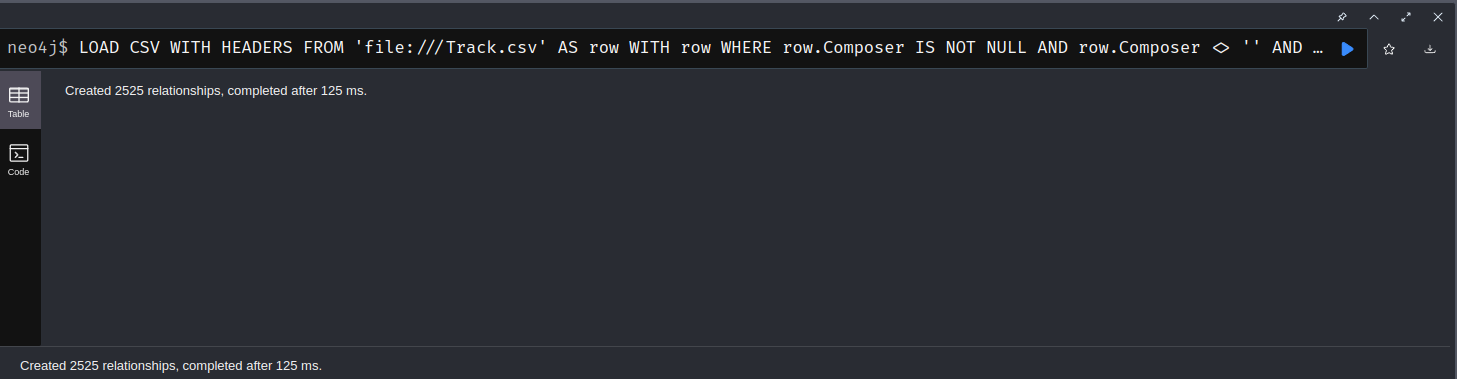

**Result:** This shows that the query ran successfully and produced 2,525 relationships.


### 2.4 Graph Verification

After establishing all relationships, I verified the graph structure by visualizing the interconnected relationships between nodes. The following query retrieves a sample of the complete relationship paths from Artist through Album and Track to Genre:

```
MATCH (a:Artist)-[:RELEASED]->(alb:Album)-[:CONTAINS]->(t:Track)-[:IN_GENRE]->(g:Genre)
RETURN a, alb, t, g
LIMIT 25;
```

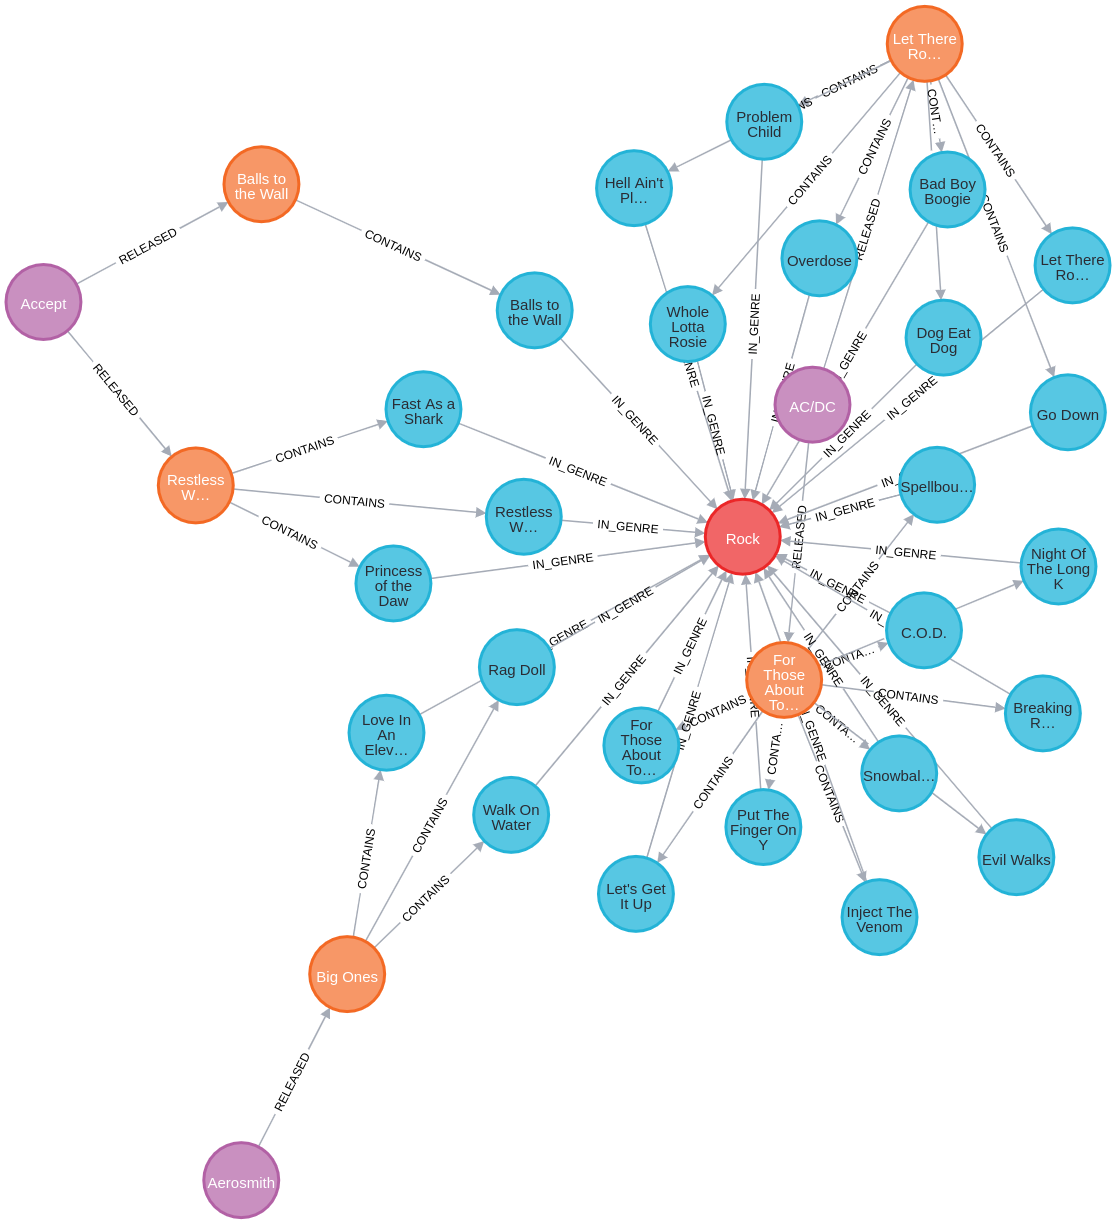

**Visualization Analysis:**
This shows the graphical representation of the full relationship paths from Artists to their released Albums that contain Tracks in Genres, limited to 25 complete paths for visual clarity. The visualization demonstrates that:
- Artists are correctly connected to their Albums via RELEASED relationships
- Albums are properly linked to their Tracks via CONTAINS relationships
- Tracks are accurately associated with Genres via IN_GENRE relationships
- The graph navigation behaves as anticipated, allowing intuitive traversal from Artists through Albums and Tracks to Genres
- The interconnected structure enables efficient path-based queries without requiring complex joins


# 3. Queries


### 3a. Tracks from 'Jazz' genre composed by 'Miles Davis'

**Query:**
```cypher
MATCH (g:Genre {name: 'Jazz'})<-[:IN_GENRE]-(t:Track)-[:COMPOSED_BY]->(c:Composer {name: 'Miles Davis'})
RETURN t
```

**Explanation:**
This query traverses the graph by matching Tracks that have both an ```IN_GENRE``` relationship to a Genre node with name 'Jazz' and a ```COMPOSED_BY``` relationship to a Composer node with name 'Miles Davis'. The query starts from the Genre and Composer nodes, then follows the relationships to find the connecting Track nodes.

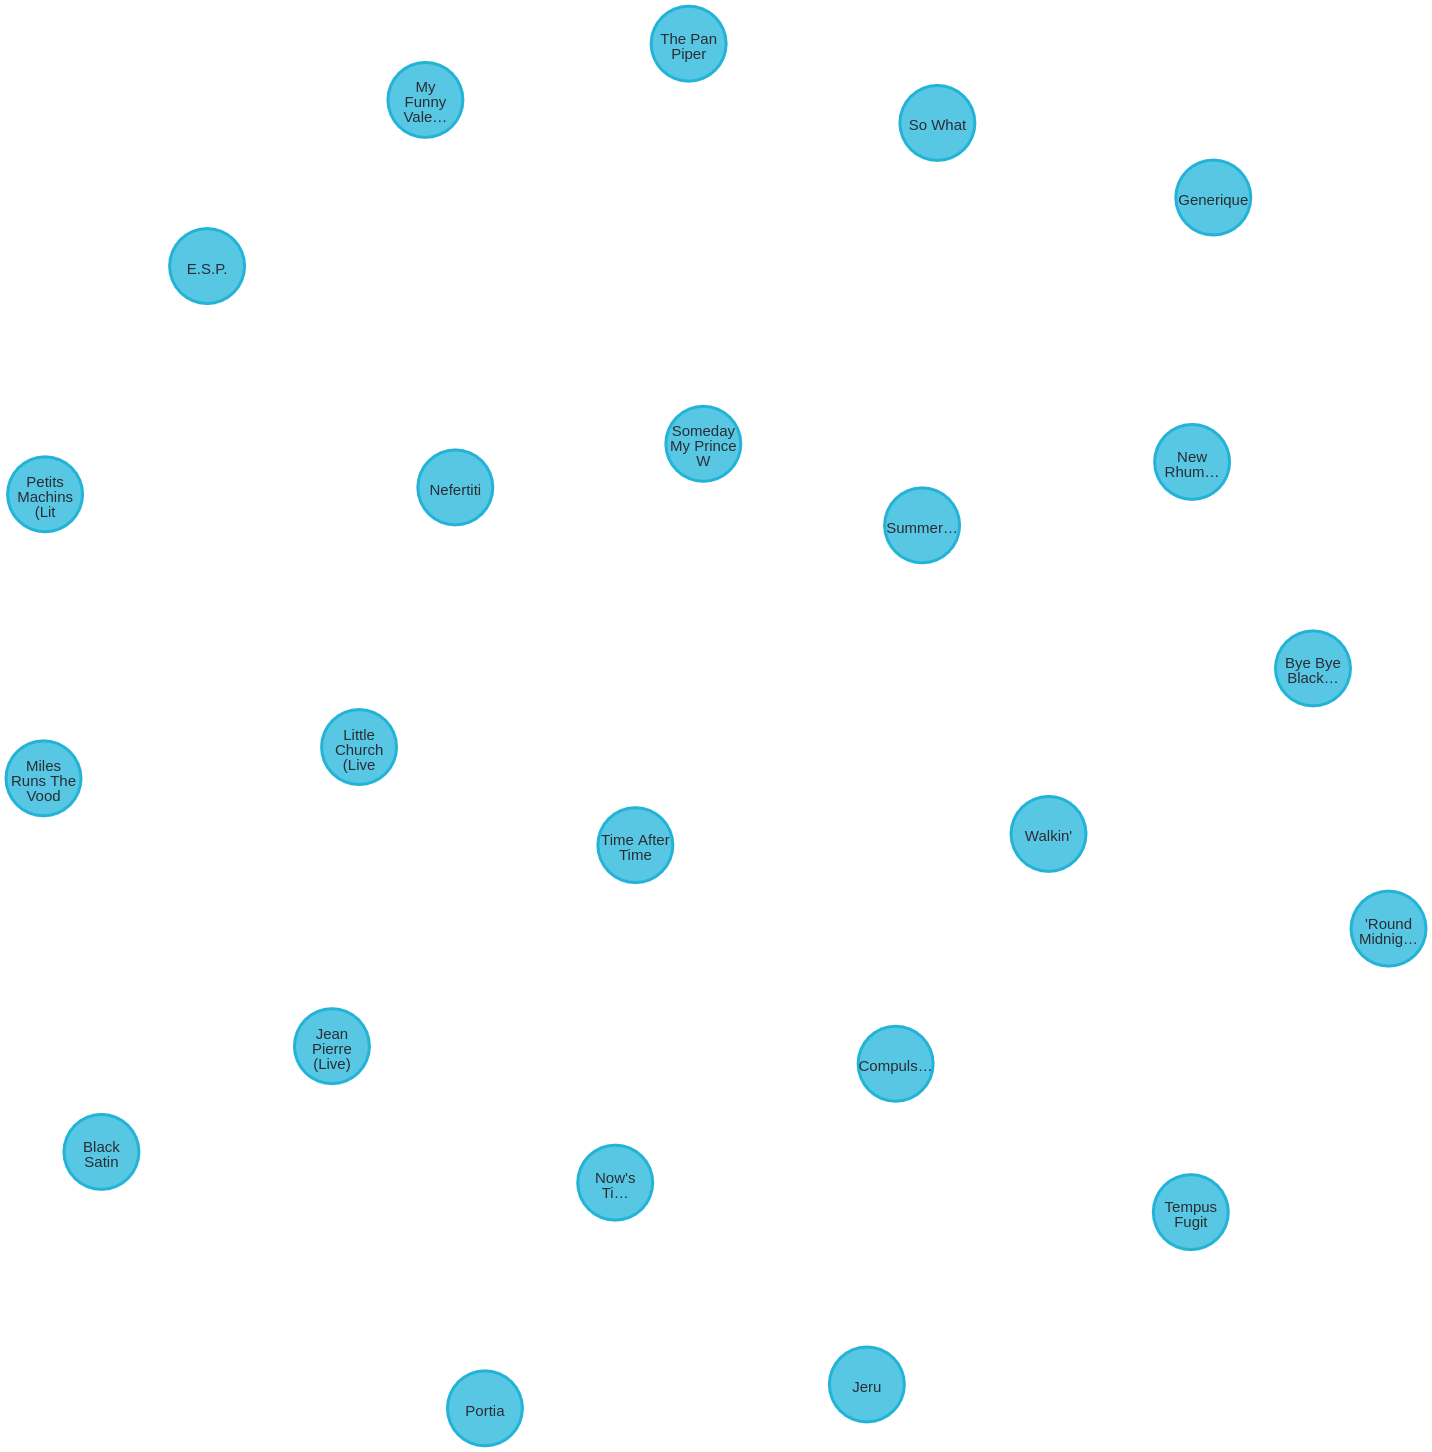

**Result:** 23 tracks returned


### 3b. Artists with Tracks in 'AAC audio file' media type

**Query:**
```cypher
MATCH (:MediaType {name:'AAC audio file'})<-[:OF_MEDIA_TYPE]-(:Track)<-[:CONTAINS]-(:Album)<-[:RELEASED]-(a:Artist)
RETURN DISTINCT a
```

**Explanation:**
This returns the 1 Artist named as "Frank Zappa & Captain Beefheart".
This query traverses multiple relationships in reverse direction: starting from a MediaType node with name 'AAC audio file', it follows the ```OF_MEDIA_TYPE``` relationship to Tracks, then the ```CONTAINS``` relationship to Albums, and finally the ```RELEASED``` relationship to Artists. The ```DISTINCT``` keyword ensures each Artist is returned only once, even if they have multiple tracks in this media type. 

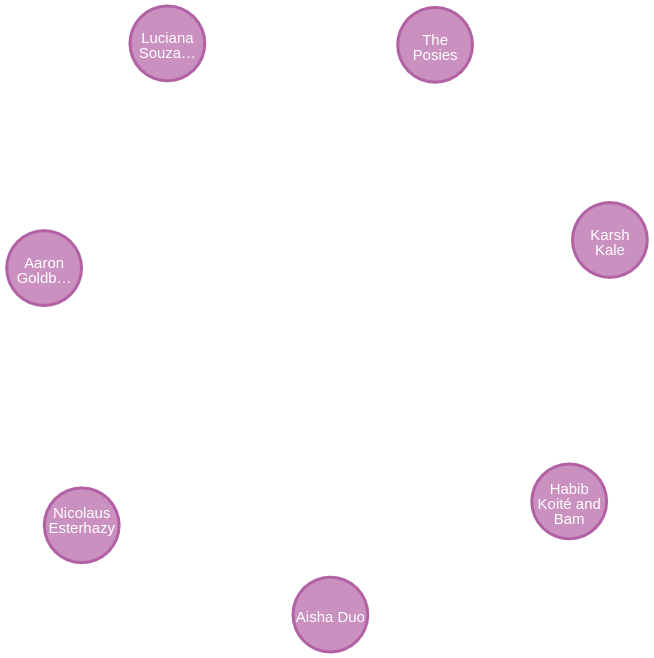

**Result:** 7 artists returned


### 3c. Artist associated with album 'Bongo Fury'

**Query:**
```cypher
MATCH (a:Artist)-[:RELEASED]->(alb:Album {title:'Bongo Fury'})
RETURN a
```

**Explanation:**
This returns the 1 Artist named as "Frank Zappa & Captain Beefheart".
This query finds the Artist who released a specific Album by matching an Album node with title 'Bongo Fury' and following the ```RELEASED``` relationship back to the Artist. The query uses a property filter on the Album node to find the specific album, then traverses the relationship to return the associated Artist. This demonstrates simple relationship traversal with property filtering.

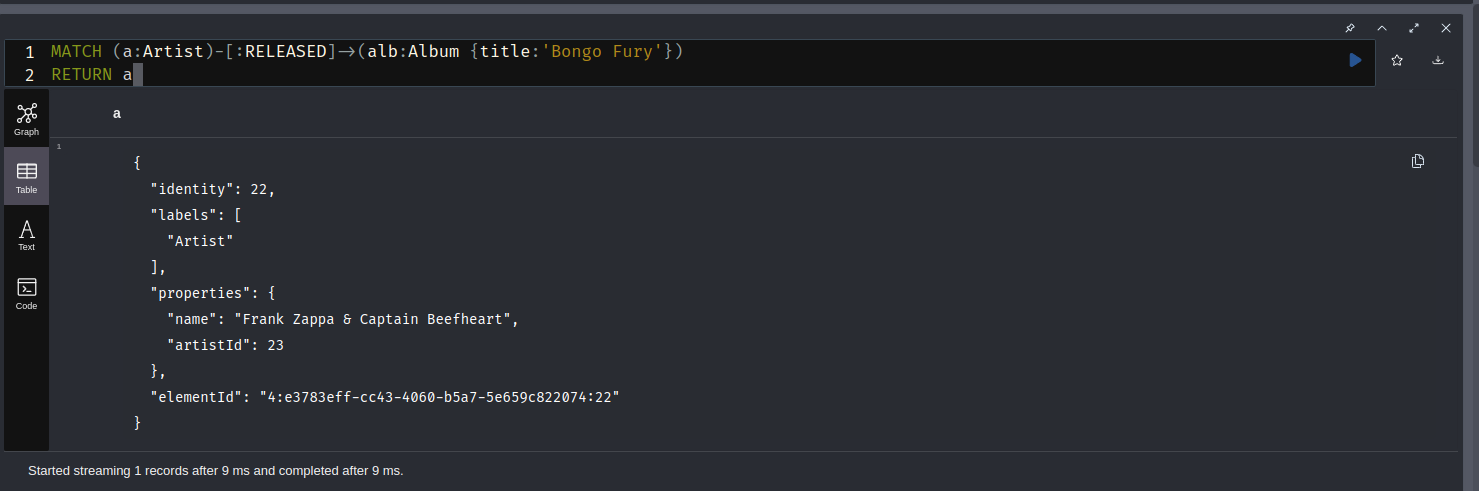

**Result:** 1 artist returned


### 3d. Tracks from album 'Coda' by artist 'Led Zeppelin'

**Query:**
```cypher
MATCH (a:Artist {name: 'Led Zeppelin'})-[:RELEASED]->(alb:Album {title: 'Coda'})-[:CONTAINS]->(t:Track)
RETURN DISTINCT t
```

**Explanation:**
This query traverses a path from Artist to Album to Track: it matches an Artist with name 'Led Zeppelin', follows the ```RELEASED``` relationship to an Album with title 'Coda', then follows the ```CONTAINS``` relationship to all Tracks in that album. The ```DISTINCT``` keyword ensures each Track is returned only once. 

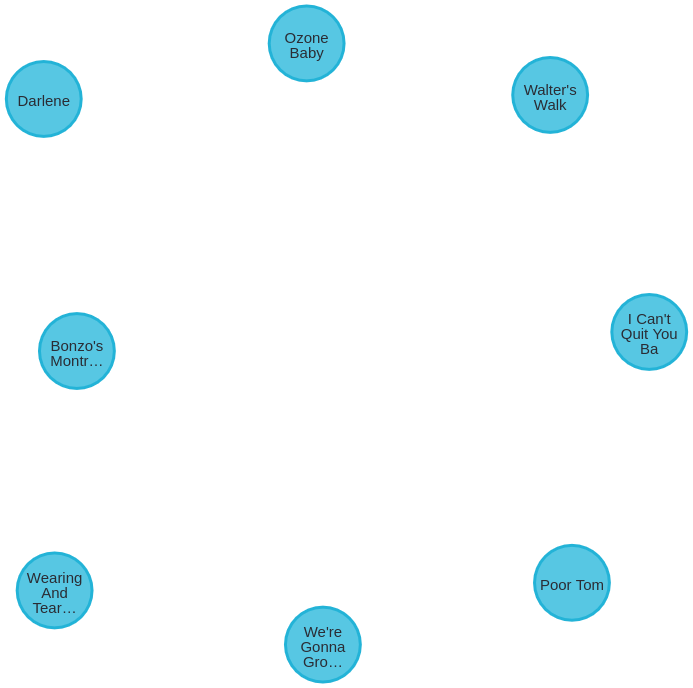

**Result:** 8 tracks returned


### 3e. Albums containing Tracks composed by 'Alanis Morissette & Glenn Ballard'

**Query:**
```cypher
MATCH (t:Track)-[:COMPOSED_BY]->(:Composer {name: 'Alanis Morissette & Glenn Ballard'})
MATCH (a:Album)-[:CONTAINS]->(t:Track)
RETURN DISTINCT a
```

**Explanation:**
This query uses two ```MATCH``` clauses: first, it finds all Tracks that have a ```COMPOSED_BY``` relationship to the Composer with name 'Alanis Morissette & Glenn Ballard'. Then, it finds all Albums that have a ```CONTAINS``` relationship to those Tracks. The ```DISTINCT``` keyword ensures each Album is returned only once, even if it contains multiple tracks by this composer. 

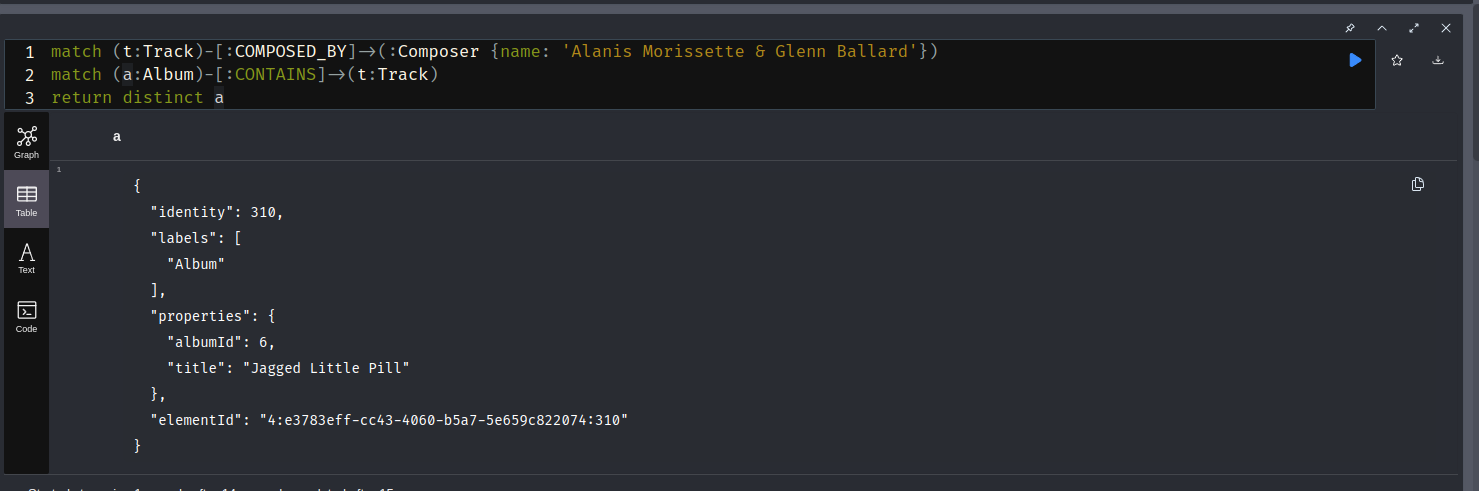

**Result:** 1 album returned


### 3f. Albums containing Tracks with no Composer specified

**Query:**
```cypher
MATCH (a:Album)-[:CONTAINS]->(t:Track)
WHERE NOT (t)-[:COMPOSED_BY]->()
RETURN DISTINCT a.title AS albumName
```

**Explanation:**
This query finds Albums that contain Tracks which have no ```COMPOSED_BY``` relationship. It matches Albums with ```CONTAINS``` relationships to Tracks, then uses a ```WHERE``` clause with ```NOT``` to filter for Tracks that do not have a ```COMPOSED_BY``` relationship to any Composer node. The ```DISTINCT``` keyword ensures each album name is returned only once, and we return only the album title property. 

**Query Results:**
```csv
﻿albumName
Balls to the Wall
Warner 25 Anos
Alcohol Fueled Brewtality Live! [Disc 1]
Alcohol Fueled Brewtality Live! [Disc 2]
Black Sabbath
Body Count
Sozinho Remix Ao Vivo
Minha Historia
Da Lama Ao Caos
Na Pista
Carnaval 2001
Heart of the Night
Meus Momentos
The Best of Ed Motta
Up An' Atom
Vinícius De Moraes - Sem Limite
Vozes do MPB
Cássia Eller - Coleção Sem Limite [Disc 2]
Cássia Eller - Sem Limite [Disc 1]
Vault: Def Leppard's Greatest Hits
Djavan Ao Vivo - Vol. 02
Elis Regina-Minha História
Angel Dust
Deixa Entrar
Roda De Funk
As Canções de Eu Tu Eles
Quanta Gente Veio Ver (Live)
Quanta Gente Veio ver--Bônus De Carnaval
Appetite for Destruction
Use Your Illusion I
A Matter of Life and Death
Live After Death
Live At Donington 1992 (Disc 1)
Live At Donington 1992 (Disc 2)
Rock In Rio [CD1]
Surfing with the Alien (Remastered)
Jorge Ben Jor 25 Anos
Jota Quest-1995
Living After Midnight
Greatest Hits
Lulu Santos - RCA 100 Anos De Música - Álbum 01
Lulu Santos - RCA 100 Anos De Música - Álbum 02
Seek And Shall Find: More Of The Best (1963-1981)
The Best Of Men At Work
Compositores
Olodum
Arquivo Os Paralamas Do Sucesso
Os Cães Ladram Mas A Caravana Não Pára
Raul Seixas
Santana Live
"Pure Cult: The Best Of The Cult (For Rockers, Ravers, Lovers & Sinners) [UK]"
Serie Sem Limite (Disc 2)
Battlestar Galactica: The Story So Far
"Battlestar Galactica, Season 3"
"Heroes, Season 1"
"Lost, Season 3"
"Lost, Season 1"
"Lost, Season 2"
UB40 The Best Of - Volume Two [UK]
Vinicius De Moraes
"The Office, Season 1"
"The Office, Season 2"
"The Office, Season 3"
"Battlestar Galactica (Classic), Season 1"
Aquaman
Instant Karma: The Amnesty International Campaign to Save Darfur
Speak of the Devil
20th Century Masters - The Millennium Collection: The Best of Scorpions
Radio Brasil (O Som da Jovem Vanguarda) - Seleccao de Henrique Amaro
Cake: B-Sides and Rarities
"LOST, Season 4"
Temple of the Dog
Revelations
Prokofiev: Romeo & Juliet
SCRIABIN: Vers la flamme
Back to Black
Frank
Carried to Dust (Bonus Track Version)
Mendelssohn: A Midsummer Night's Dream
Liszt - 12 Études D'Execution Transcendante
"Great Recordings of the Century - Shubert: Schwanengesang, 4 Lieder"
Respighi:Pines of Rome
```

**Result:** 82 albums returned (tracks without composers)
